# POC SDD-LCA 2026

Ce notebook propose un **deroule de presentation scientifique**, mais lisible pour un public operationnel.

Objectif : montrer que le `State-Dependent Dynamic LCA (SDD)` n'est pas seulement une LCA plus detaillee, mais une methode qui :
- capte des impacts rates par la `LCA classique` et la `LCA dynamique` ;
- explique **pourquoi** ces impacts apparaissent ;
- change la lecture des politiques operationnelles et des arbitrages.

Le fil narratif retenu est :
1. `LCA classique` et `LCA dynamique` sont presque equivalentes sur ce POC.
2. Le `SDD` revele un sur-impact important.
3. Ce sur-impact vient des changements d'etat de la supply chain.
4. Cette difference compte pour comparer des politiques et prendre de meilleures decisions.

Les annexes en fin de notebook completent la lecture pour un public plus technique.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display, Markdown, Image

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'outputs_sddlca_poc').exists():
    NOTEBOOK_DIR = Path('/workspaces/lca-simu/POC2026')

CSV_DIR = NOTEBOOK_DIR / 'outputs_sddlca_poc' / 'csv'
IMG_DIR = NOTEBOOK_DIR / 'outputs_sddlca_poc' / 'images'

comparison = pd.read_csv(CSV_DIR / 'poc_lca_method_comparison.csv')
key_metrics = pd.read_csv(CSV_DIR / 'poc_key_metrics.csv')
decision_summary = pd.read_csv(CSV_DIR / 'poc_policy_decision_summary.csv')
breakdown = pd.read_csv(CSV_DIR / 'poc_lca_breakdown.csv')

def show_image(filename: str, width: int = 1000):
    return Image(filename=str(IMG_DIR / filename), width=width)

display(Markdown('## Donnees chargees'))
display(comparison.round(2))


## Donnees chargees

,method,total_kgCO2e,delta_vs_classical,delta_vs_classical_pct
0,Classical LCA,3693.54,0.00,0.00
1,Dynamic LCA,3696.37,2.84,0.08
2,State-Dependent Dynamic LCA,4903.68,1210.14,32.76


## Selection resserree des graphes a conserver

Pour une presentation courte, je conserverais prioritairement :

1. `poc_weekly_impact_comparison.png`
   pour montrer que l'ecart apparait dans le temps.
2. `poc_sdd_gap_drivers.png`
   pour montrer d'ou vient l'ecart du SDD.
3. `poc_state_space_method_comparison.png`
   pour montrer ce que voit chaque methode.
4. `poc_policy_method_gap.png`
   pour montrer que l'ecart reste present quand on compare des politiques.
5. `poc_policy_decision_frontier.png`
   pour montrer l'apport du SDD a la decision.

Les annexes utiles sont ensuite :
- `poc_policy_causal_attribution.png`
- `poc_decision_reversal.png`
- `poc_sensitivity_volume_intensity.png`
- `poc_source_traceability.png`
- `poc_state_space_projection.png`


## Vocabulaire minimal du POC

Pour eviter les ambiguities pendant la presentation, voici le vocabulaire a utiliser de facon stable :

- `Production utile` : nombre de produits finis fabriques sans rebut pendant la semaine. C'est un **flux**.
- `Expeditions client` : nombre de produits finis effectivement envoyes au client pendant la semaine. C'est un **flux aval**.
- `Stock MP` : stock de matieres premieres disponible pour produire.
- `Stock PF` : stock de produits finis deja fabriques mais pas encore expedies.
- `Stock total` : `stock MP + stock PF`. C'est une vue agregee, utile pour la `LCA classique` et la `LCA dynamique`.
- `Matieres en transit` : matieres deja commandees mais pas encore recues. Ce n'est **pas** une expedition client.
- `Backlog` : demande non servie, reportee a la periode suivante.
- `Backup` : fournisseur ou source de secours, plus carbones dans ce POC.
- `Scrap` : matiere et energie consommees pour produire des unites qui ne seront finalement pas livrees.

Point important :
- la `LCA classique` voit surtout des agregats ;
- la `LCA dynamique` voit des evolutions temporelles ;
- le `SDD` voit les evolutions temporelles **et** les etats operationnels qui expliquent ces evolutions.


## 0. Mise en contexte operationnelle

Avant d'entrer dans la comparaison des methodes, il est utile de fixer **le systeme physique** et **la chronologie des evenements**.

Pourquoi cette introduction est utile :
- elle ancre les graphes carbone dans une supply chain concrete ;
- elle permet de visualiser les moments ou le systeme change de regime ;
- elle rend plus intuitive la lecture du `SDD`, qui depend justement de ces changements d'etat.

Comment lire cette introduction :
- le schema de supply chain rappelle la structure du POC : fournisseurs, usine, entrepot, client ;
- la chronologie montre les evenements operationnels significatifs : reception du `backup`, usage du `backup`, passage en `aerien`, apparition de `scrap`.

Question importante :
- **Pourquoi commencer par cela ?**
  Parce que la these du POC est que les impacts carbone emergent de la dynamique operationnelle. Il faut donc d'abord voir le systeme et ses evenements avant d'interpreter les resultats LCA.


### Structure de la supply chain

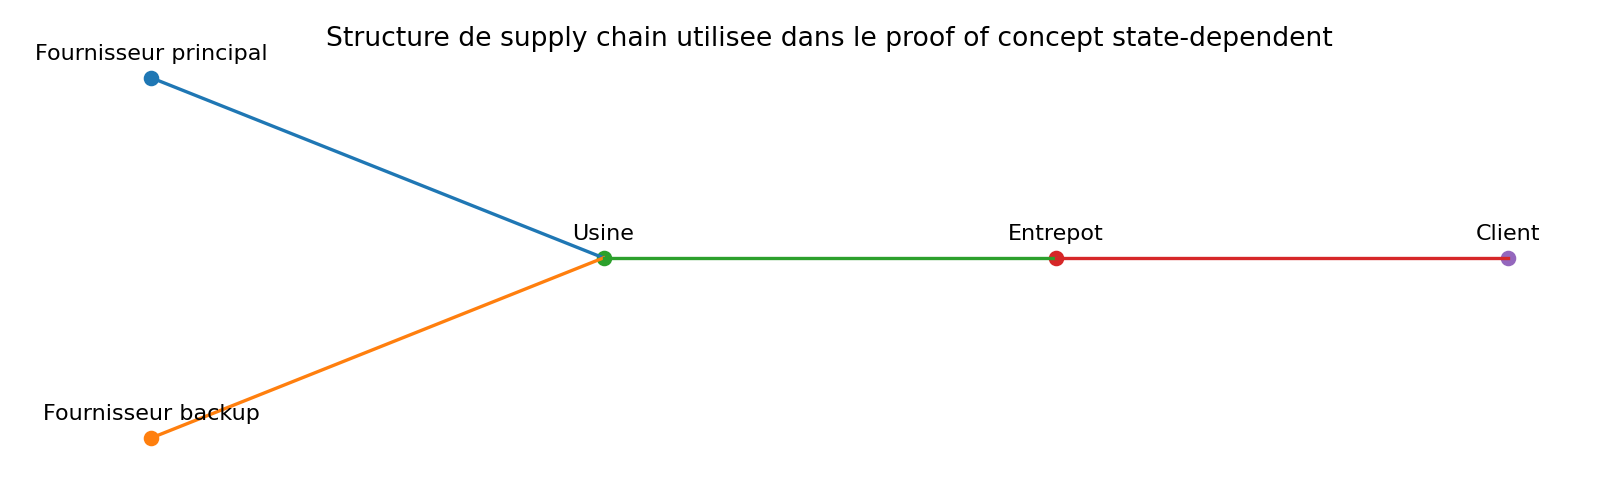

### Chronologie des evenements operationnels

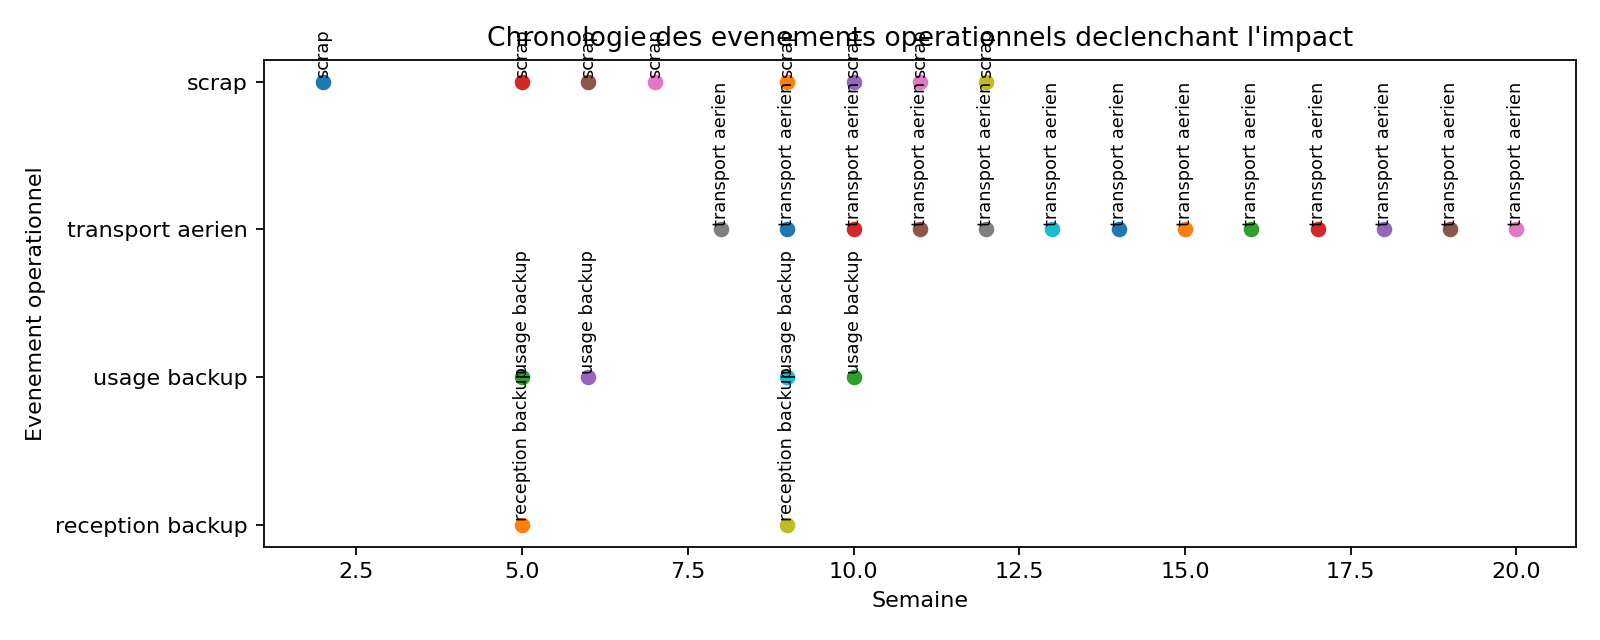

In [2]:
display(Markdown('### Structure de la supply chain'))
display(show_image('poc_supply_chain_schematic.png', width=850))
display(Markdown('### Chronologie des evenements operationnels'))
display(show_image('poc_event_timeline.png', width=900))


## 1. Resultat principal

Le premier message a faire passer est simple : dans ce POC, la `LCA classique` et la `LCA dynamique` sont presque equivalentes, alors que le `SDD` revele un sur-impact important.

C'est le bon point de depart pour toute la demonstration.

In [3]:
display(Markdown('### Chiffres cles'))
display(comparison.round(2))

display(Markdown('### Metriques operationnelles cles'))
display(key_metrics.head(10))

### Chiffres cles

,method,total_kgCO2e,delta_vs_classical,delta_vs_classical_pct
0,Classical LCA,3693.54,0.00,0.00
1,Dynamic LCA,3696.37,2.84,0.08
2,State-Dependent Dynamic LCA,4903.68,1210.14,32.76


### Metriques operationnelles cles

,metric,value
0,Weeks with air outbound,13.00
1,Weeks with backup supplier activated,2.00
2,Weeks with backup material consumed,4.00
3,Weeks with carbon-aware throttling,0.00
4,Total scrap units,6.90
5,Peak backlog,77.90
6,Ending backlog,76.90
7,Weeks with backlog,16.00
8,Peak capacity utilization,1.00
9,Same-week service level,66.42


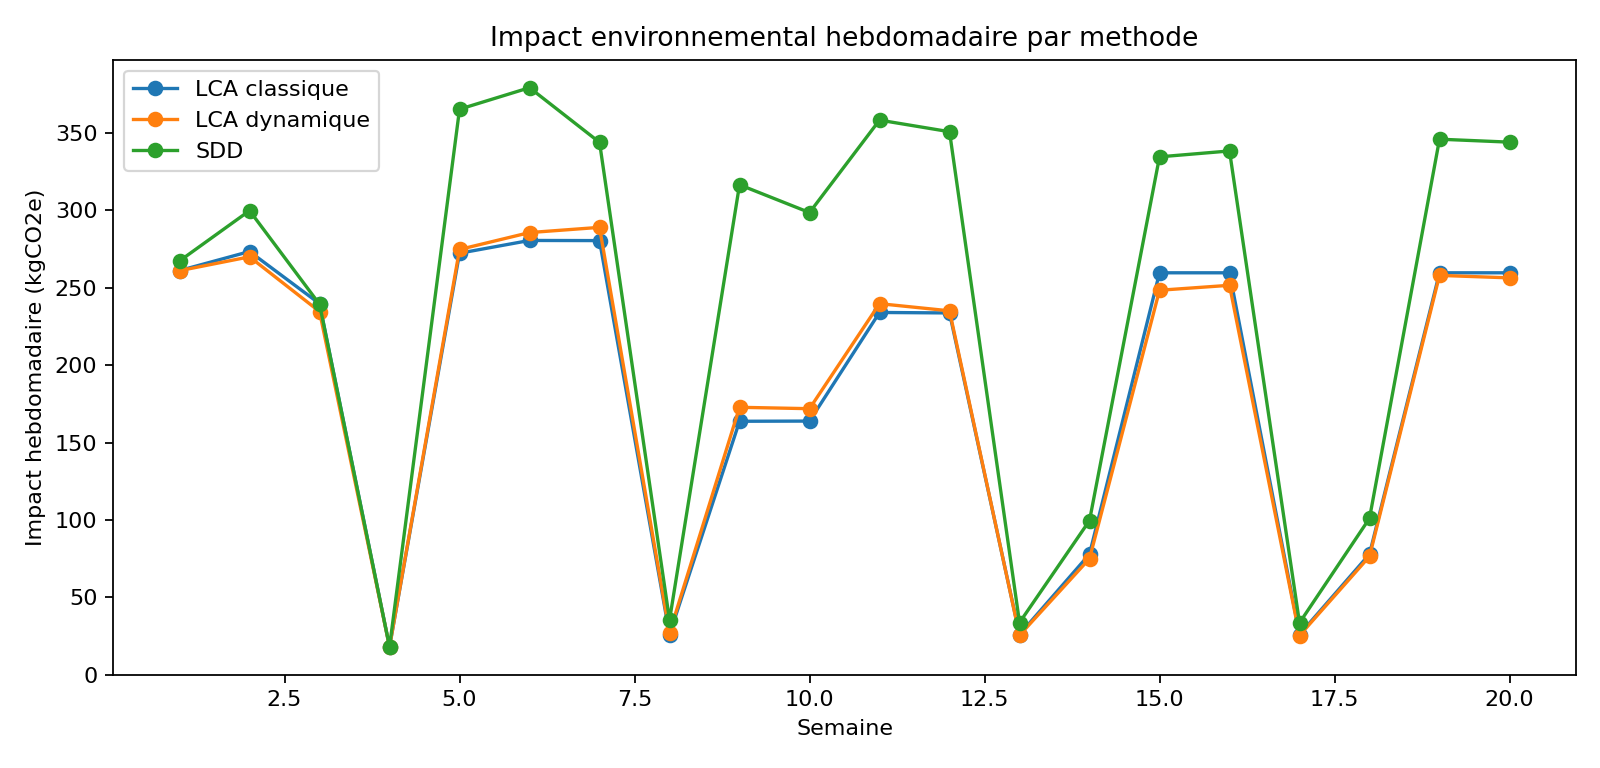

In [4]:
show_image('poc_weekly_impact_comparison.png', width=950)

**Lecture attendue**

- La `LCA classique` et la `LCA dynamique` restent presque superposees parce qu'elles reposent ici sur des representations proches : une logique nominale, peu sensible aux changements de regime.
- Le `SDD` diverge lorsque la supply chain entre dans une zone de tension operationnelle : hausse du backlog, recours au backup, basculement en aerien, augmentation du rebut.
- Le point scientifique important est que l'ecart n'est pas un simple effet de granularite temporelle : il vient de la **dependance a l'etat**.
- Le point operationnel important est qu'un systeme peut sembler stable en `LCA classique` et en `LCA dynamique`, alors qu'il est deja en train de deteriorer son profil carbone reel.

Questions auxquelles ce graphe repond :
- **Quand** l'ecart apparait-il ?
  Reponse : au moment ou la chaine change de regime.
- **Pourquoi** la `LCA dynamique` ne suffit-elle pas ?
  Reponse : parce qu'elle suit le temps, mais pas completement l'etat interne de la chaine.
- **Que signifie le decrochage du SDD ?**
  Reponse : que les emissions associees aux reactions operationnelles deviennent dominantes.



### Pourquoi la LCA dynamique ne brille-t-elle pas particulierement ici ?

Cette question est importante, car on pourrait s'attendre a ce que la `LCA dynamique` se distingue deja fortement de la `LCA classique`. Dans ce POC, ce n'est presque pas le cas.

La raison est methodologique :
- la `LCA dynamique` suit bien la variation temporelle de certains flux, notamment le facteur reseau et les volumes hebdomadaires ;
- mais elle conserve une logique operationnelle encore tres nominale ;
- elle ne porte pas explicitement les changements de regime qui dominent ici l'ecart carbone : recours a l'aerien, activation du `backup`, surconsommation sous tension et charge carbone du `scrap`.

Autrement dit :
- la `LCA dynamique` corrige **le temps** ;
- le `SDD` corrige **le temps plus l'etat**.

Dans ce POC, les facteurs temporels seuls ne suffisent pas a produire un ecart important. Le facteur reseau varie, mais cette variabilite reste secondaire par rapport aux reactions operationnelles de crise. C'est pourquoi la `LCA dynamique` reste proche de la `LCA classique`, alors que le `SDD` decroche nettement.

Question pertinente :
- **Est-ce un defaut de la LCA dynamique ?**
  Pas necessairement. Cela signifie surtout que, sur ce cas, la composante vraiment discriminante n'est pas seulement la variabilite temporelle, mais la representation explicite des regimes operationnels.
- **Y a-t-il une correction implicite apportee par le SDD ?**
  Oui. Le `SDD` corrige la sous-representation des etats critiques en reliant l'impact a la situation interne de la supply chain, et non plus seulement a une chronologie de flux.
- **Dans quel type de cas la LCA dynamique pourrait-elle mieux ressortir ?**
  Dans un systeme ou la variabilite temporelle des facteurs d'emission et des flux serait dominante, sans changement de regime operationnel majeur.


## 2. Pourquoi le SDD trouve plus d'impact

Le deuxieme message essentiel est causal : le `SDD` ne donne pas seulement un chiffre plus grand, il montre **pourquoi** l'impact augmente.

Le bon graphique est celui qui met face a face :
- ce que voit la `LCA classique` ;
- ce que voit la `LCA dynamique` ;
- ce que le `SDD` ajoute.

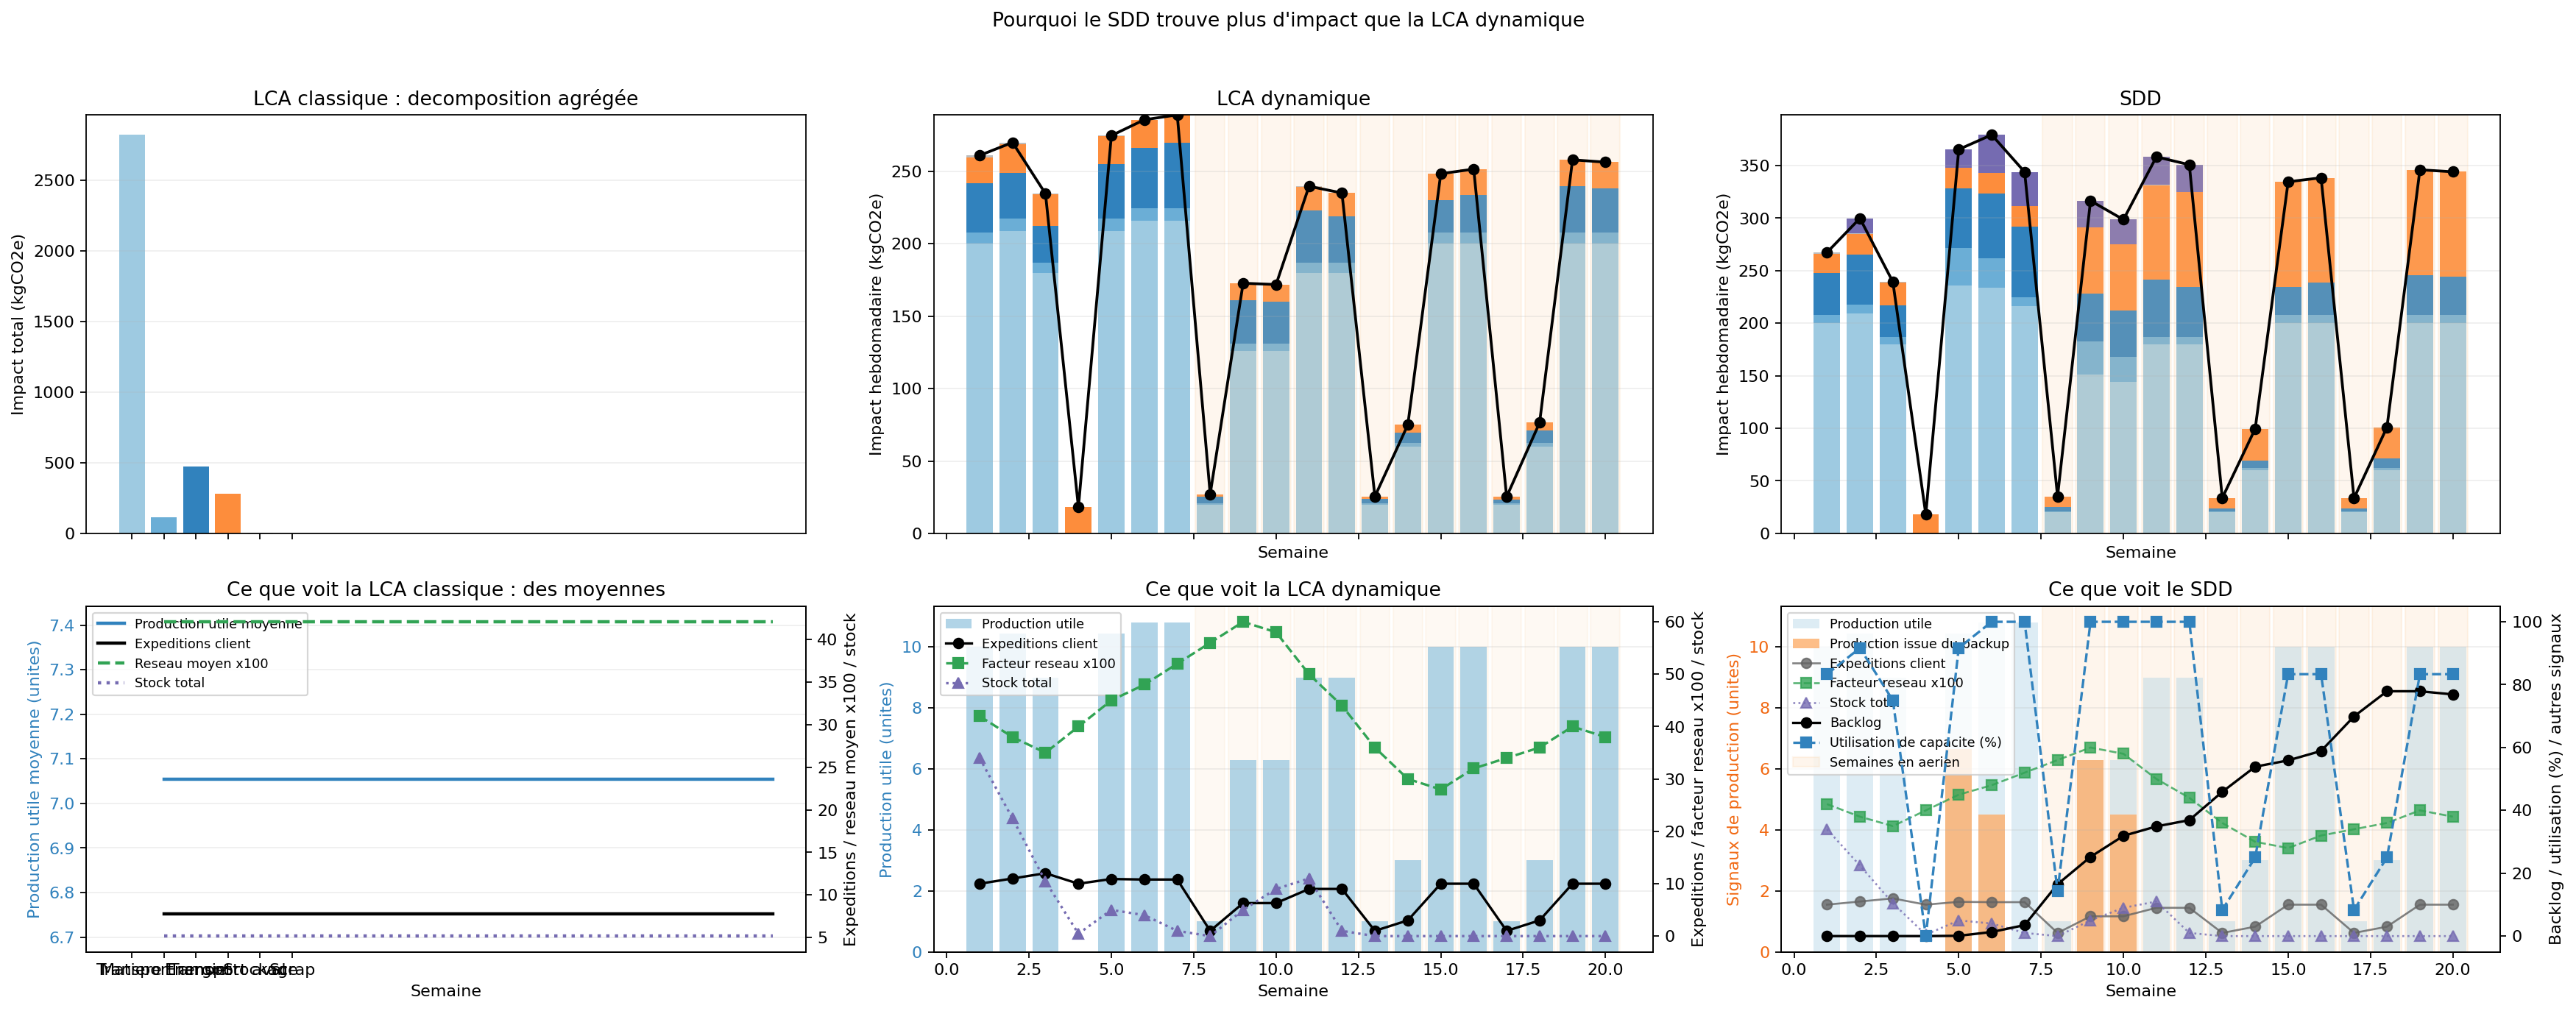

In [5]:
show_image('poc_sdd_gap_drivers.png', width=1250)

**Lecture attendue**

Ce graphe doit etre lu comme un graphe de causalite operationnelle.

- En haut, on compare la forme de representation de chaque methode :
  - `LCA classique` : decomposition agrégée ;
  - `LCA dynamique` : impacts hebdomadaires dans le temps ;
  - `SDD` : meme logique temporelle que la `LCA dynamique`, mais enrichie par les variables d'etat.
- En bas, on compare ce que chaque methode est capable d'observer.

Pourquoi le `scrap` ressort-il beaucoup plus en `SDD` ?
- Dans ce POC, la `LCA classique` et la `LCA dynamique` attribuent `0` au poste `scrap`.
- Le `SDD`, lui, calcule une charge carbone du rebut : matiere consommee, transport amont deja engage et energie deja depensee pour produire une unite qui ne sera finalement pas livree.
- En regime degrade, ce rebut devient plus important, et son contenu carbone augmente encore quand il est associe a du `backup` ou a une production sous tension.

Questions auxquelles ce graphe repond :
- **Pourquoi l'impact total du SDD augmente-t-il ?**
  Reponse : parce que le systeme reagit operationnellement a la perturbation.
- **Qu'est-ce que la `LCA dynamique` voit deja ?**
  Reponse : les flux qui varient dans le temps.
- **Qu'est-ce que le `SDD` ajoute ?**
  Reponse : les etats et les regimes qui expliquent ces flux.
- **Pourquoi le backup et l'aerien comptent-ils autant ?**
  Reponse : parce qu'ils correspondent a des modes de fonctionnement plus carbonés, declenches par l'etat de la chaine.



## 3. Ce que voit chaque methode

Ce graphe sert a poser la difference methodologique de facon simple :
- `LCA classique` : representation agregée ;
- `LCA dynamique` : representation temporelle ;
- `SDD` : representation temporelle enrichie par les etats de la supply chain.

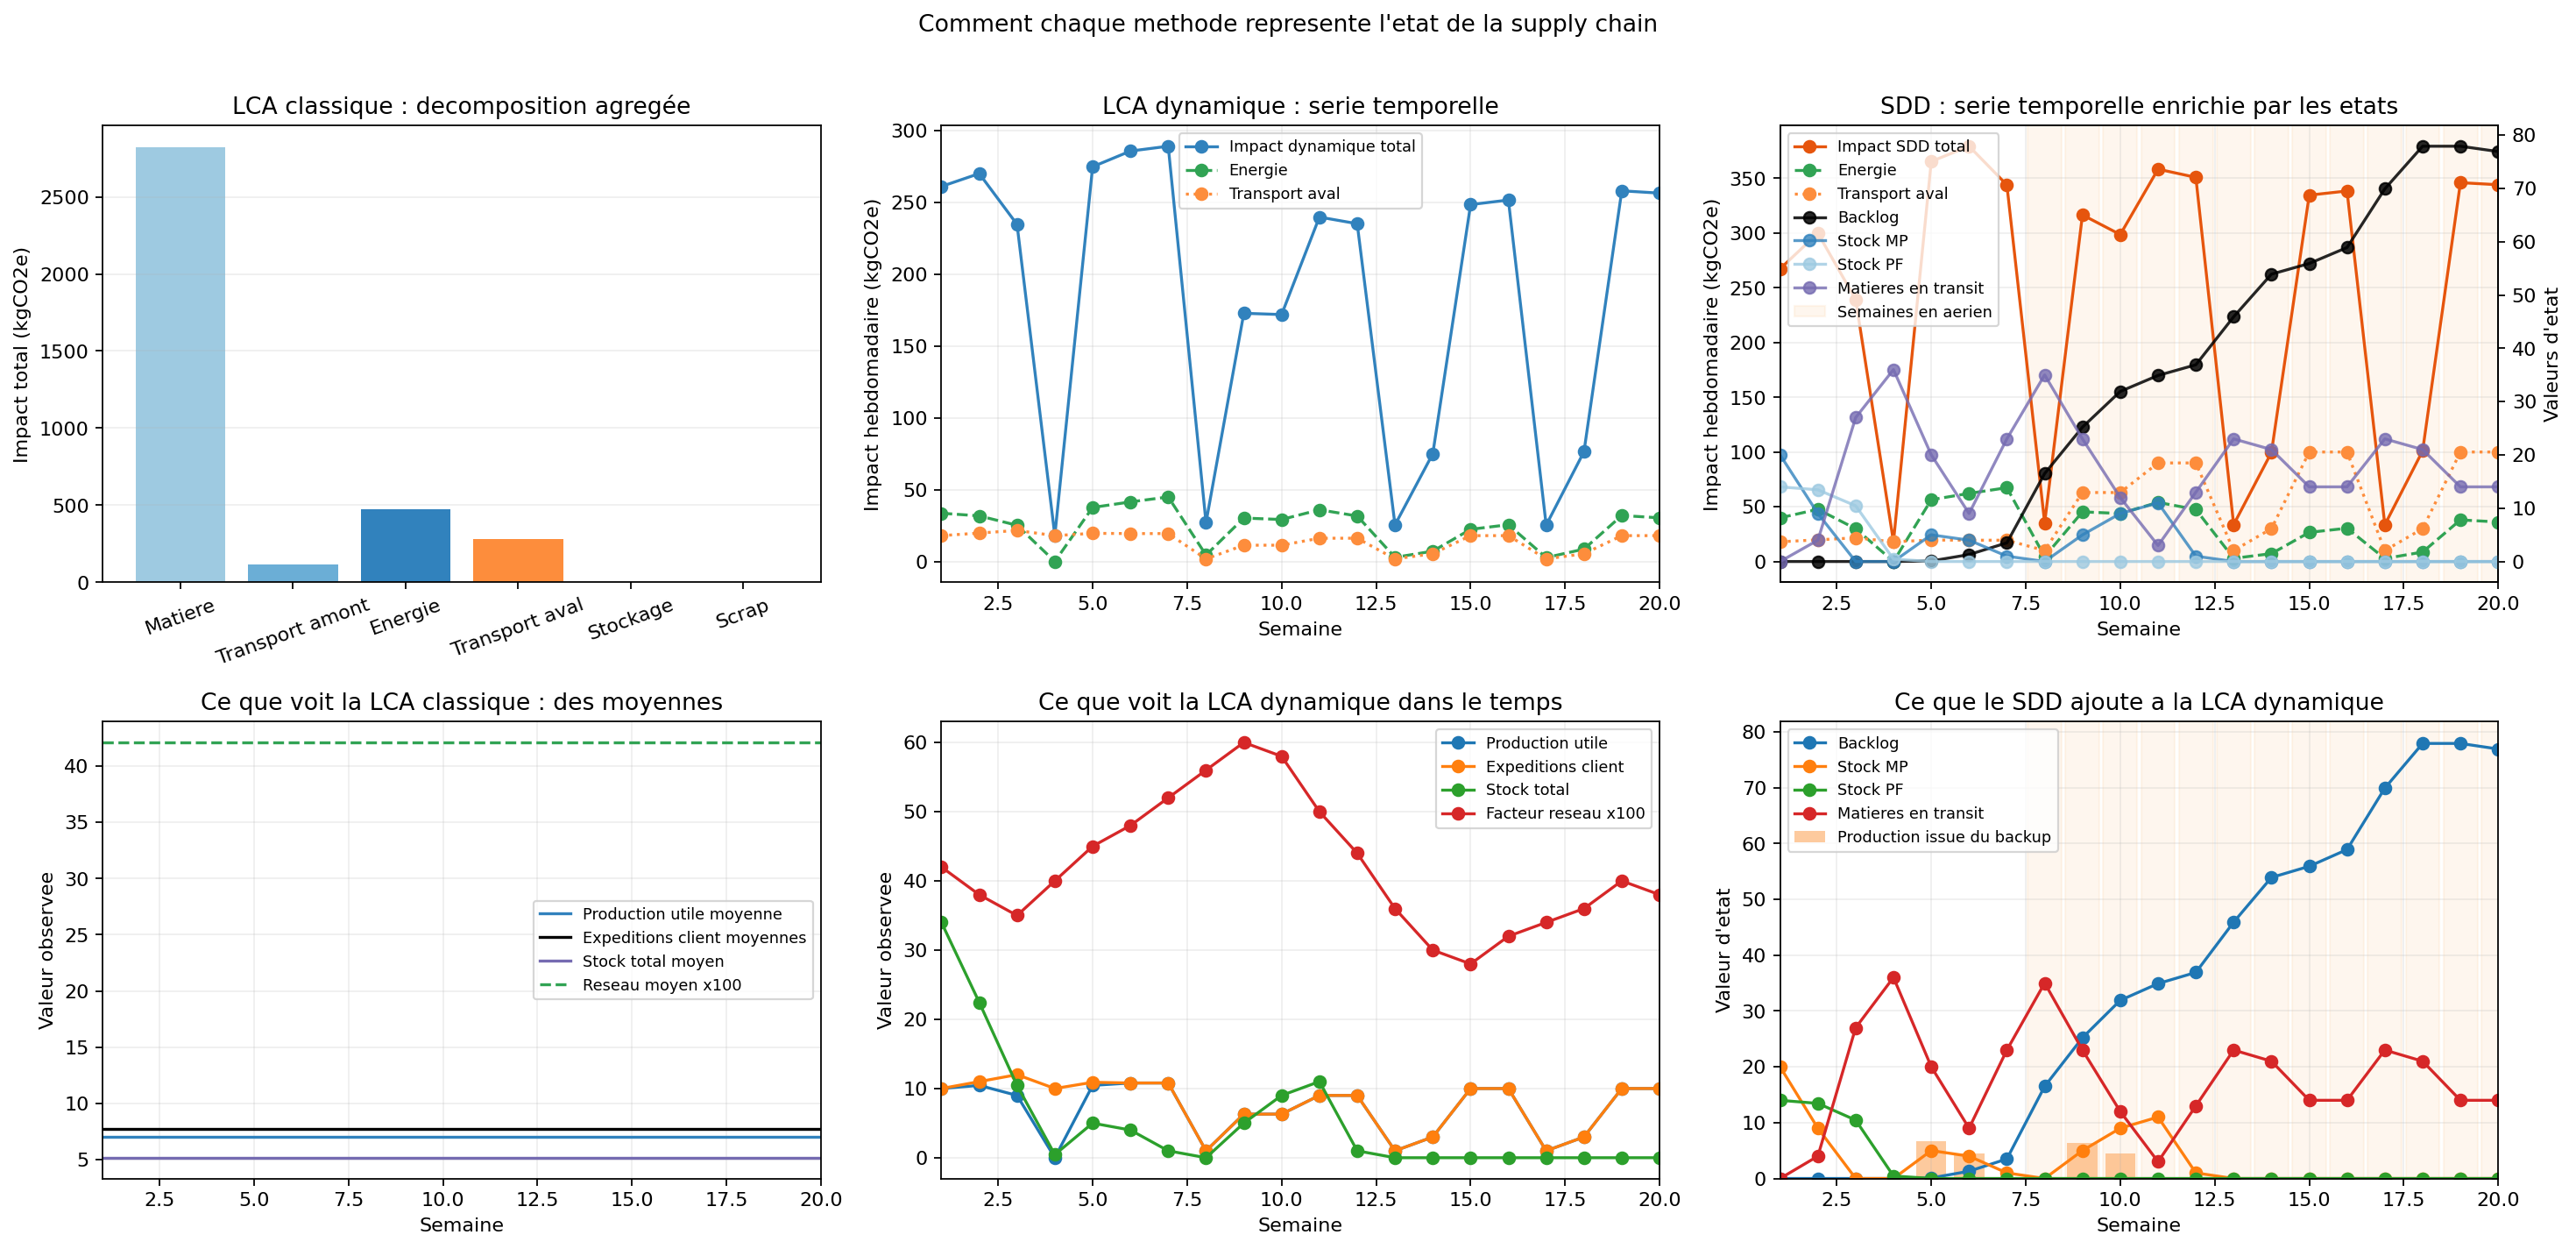

In [6]:
show_image('poc_state_space_method_comparison.png', width=1250)

**Lecture attendue**

Ce graphe ne doit pas etre compris comme un simple comparatif visuel de courbes, mais comme une comparaison de **niveaux de representation du systeme**.

- La `LCA classique` represente la supply chain comme un systeme moyen. Elle est adaptee a une lecture agregée, stable, peu sensible aux regimes.
- La `LCA dynamique` represente la supply chain comme un systeme qui varie dans le temps. Elle capte les fluctuations temporelles, mais pas encore toute la structure interne des decisions operationnelles.
- Le `SDD` represente la supply chain comme un systeme dynamique **a etat interne**. C'est ce point qui justifie l'introduction de variables comme le `backlog`, le `stock MP`, le `stock PF` et les `matieres en transit`.

Questions auxquelles ce graphe repond :
- **Pourquoi parler d'espace d'etat ?**
  Reponse : parce que l'impact depend de la situation interne de la chaine, pas seulement du temps calendaire.
- **Pourquoi distinguer `stock MP` et `stock PF` en `SDD` ?**
  Reponse : parce qu'ils n'ont pas le meme role operationnel ni la meme signification carbone.
- **Pourquoi garder `stock total` pour les autres methodes ?**
  Reponse : parce que cela illustre leur lecture plus agregee.



## 4. Ce que cela change pour comparer des politiques

Une fois la logique comprise sur le cas de base, il faut montrer que l'ecart reste present quand on compare des politiques de pilotage.

Le graphe suivant est tres utile parce qu'il rend visible, pour chaque politique, le saut entre `LCA dynamique` et `SDD`.

In [7]:
cols = [
    'policy_label',
    'same_week_service_pct',
    'total_cost',
    'classical_total_kgCO2e',
    'dynamic_total_kgCO2e',
    'sddlca_total_kgCO2e',
]
display(decision_summary[cols].round(2))

,policy_label,same_week_service_pct,total_cost,classical_total_kgCO2e,dynamic_total_kgCO2e,sddlca_total_kgCO2e
0,Reference,66.42,22519.55,3693.54,3696.37,4903.68
1,Backup anticipe,74.70,22805.28,4234.30,4226.06,6112.89
2,Stock tampon,73.49,21404.28,4093.05,4084.45,5086.71
3,Discipline carbone,66.16,22313.34,3651.96,3655.57,4729.26
4,Service prioritaire,73.49,21566.28,4093.05,4084.45,5160.51


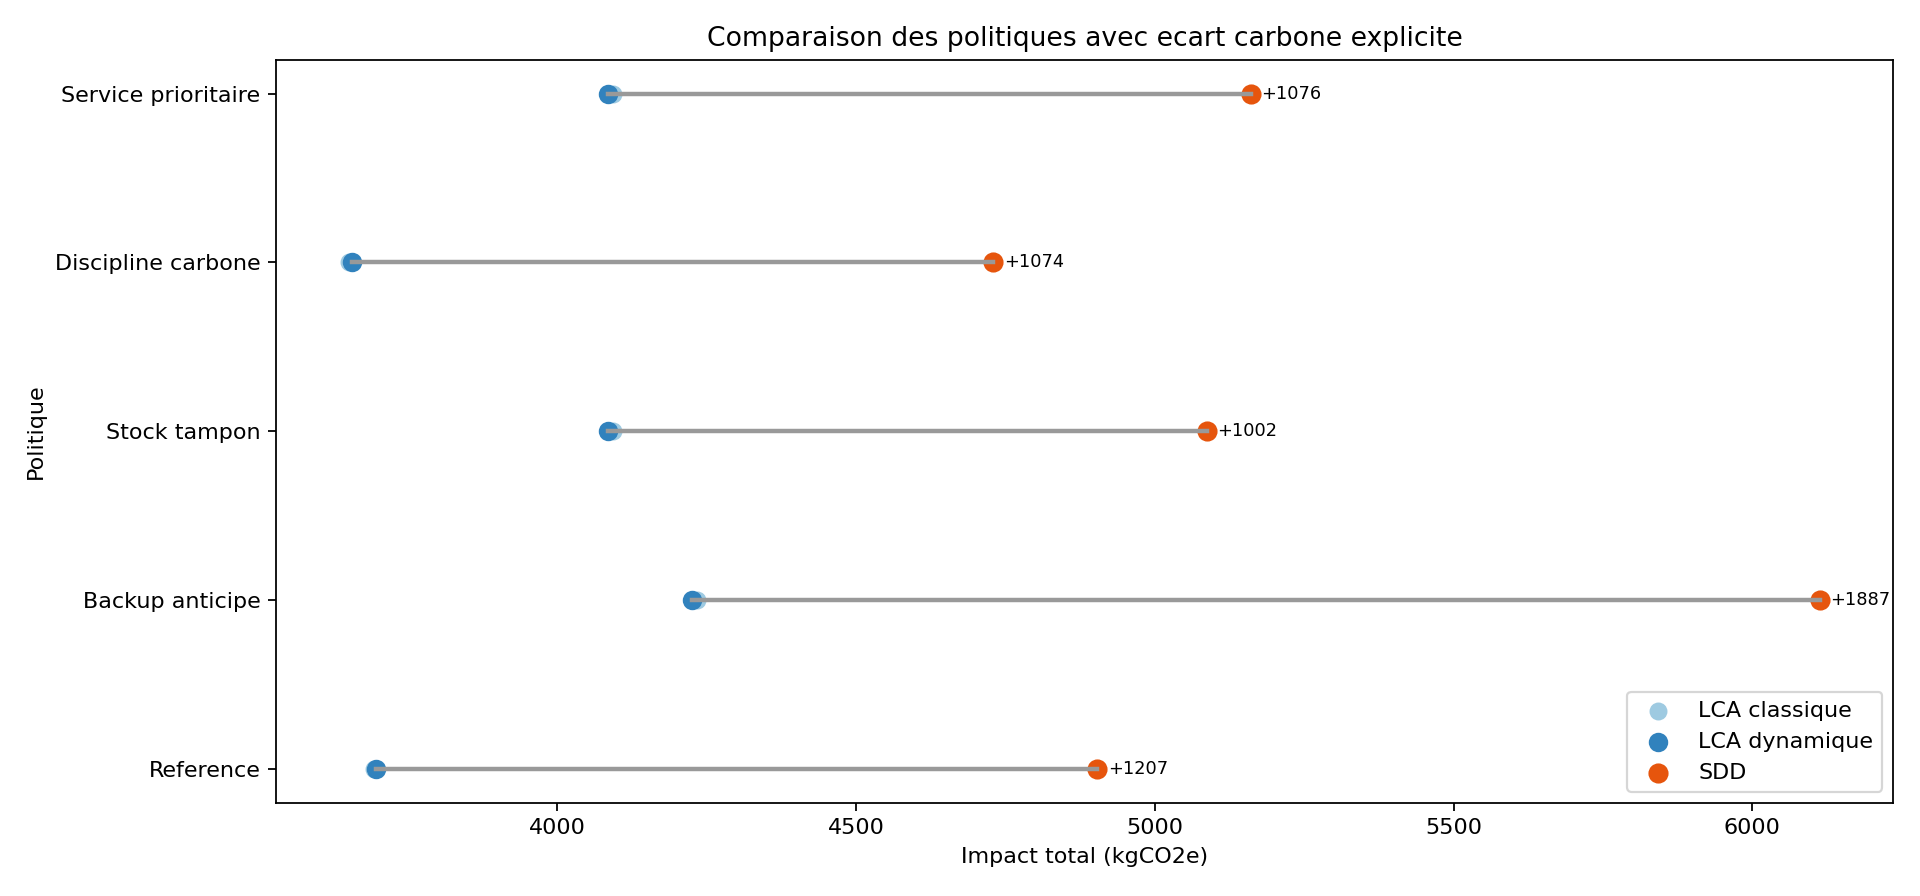

In [8]:
show_image('poc_policy_method_gap.png', width=1150)

## 5. Ce que cela change pour la decision

Le dernier message du coeur de presentation est que le `SDD` ne sert pas seulement a mieux mesurer : il sert a **mieux arbitrer** entre service, cout et carbone.

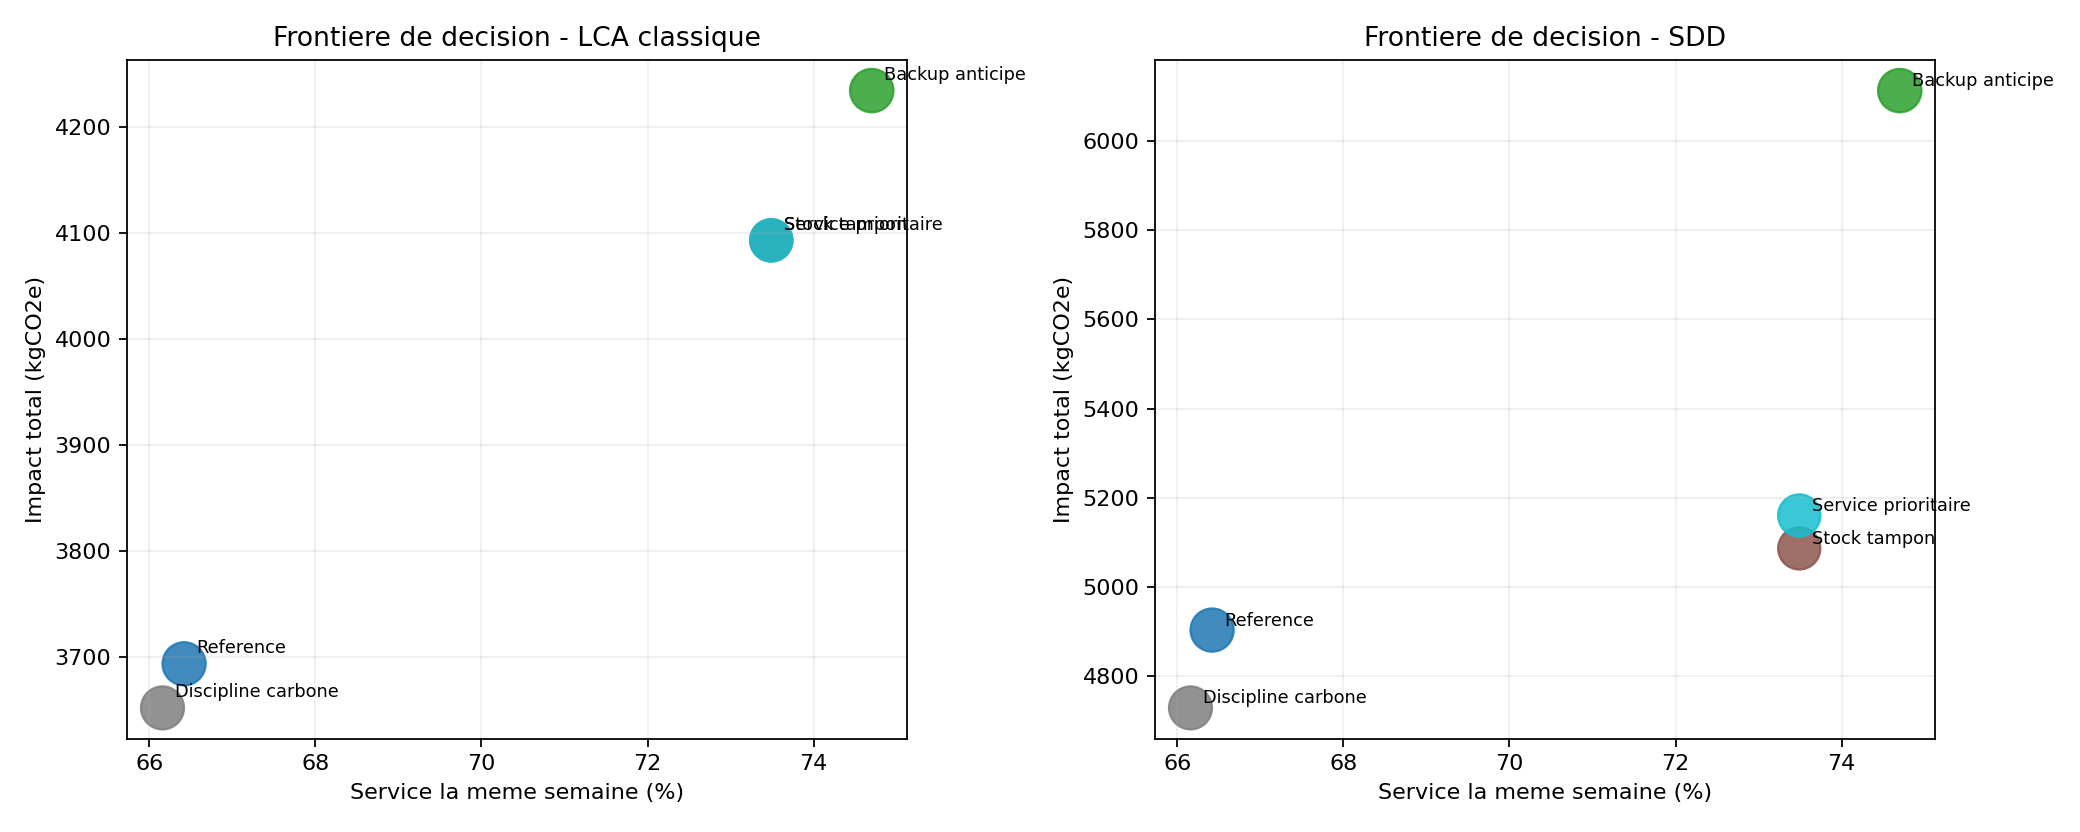

In [9]:
show_image('poc_policy_decision_frontier.png', width=1100)

**Lecture attendue**

- La frontiere de decision ne repond pas a une question purement carbone ; elle repond a une question de **pilotage**.
- L'axe horizontal mesure le service, l'axe vertical le carbone, et la taille des bulles represente le cout total.
- Une politique qui semble acceptable sous `LCA classique` ou `LCA dynamique` peut devenir moins desirable sous `SDD` si elle repose en pratique sur plus d'aerien, plus de backup ou plus de tension operationnelle.

Questions auxquelles ce graphe repond :
- **La politique la plus service est-elle aussi la plus sobre ?**
  Reponse : pas necessairement.
- **Le `SDD` change-t-il seulement la quantification ou aussi le classement ?**
  Reponse : il peut changer le classement et donc l'arbitrage.
- **Pourquoi ce graphe est-il important pour l'operationnel ?**
  Reponse : parce qu'il reconnecte la question carbone avec les questions de service et de cout, qui sont les vraies contraintes de pilotage.



## Conclusion du coeur de presentation

Le recit que je presenterais est le suivant :

1. `LCA classique` et `LCA dynamique` racontent presque la meme histoire sur ce cas.
2. Le `SDD` revele un sur-impact important.
3. Ce sur-impact vient des **etats operationnels** de la supply chain.
4. Cette difference change la comparaison entre politiques et la lecture des arbitrages.

En une phrase : le `SDD` ne sert pas seulement a calculer autrement, il sert a **representer correctement la dynamique operationnelle qui produit l'impact**.

# Annexes

Les annexes ci-dessous permettent de completer la demonstration pour un public plus technique, tout en restant lisibles pour l'operationnel.

## Annexe A. Decomposition des impacts par politique

Ce graphe sert a montrer quels postes d'impact deviennent dominants selon la politique retenue.

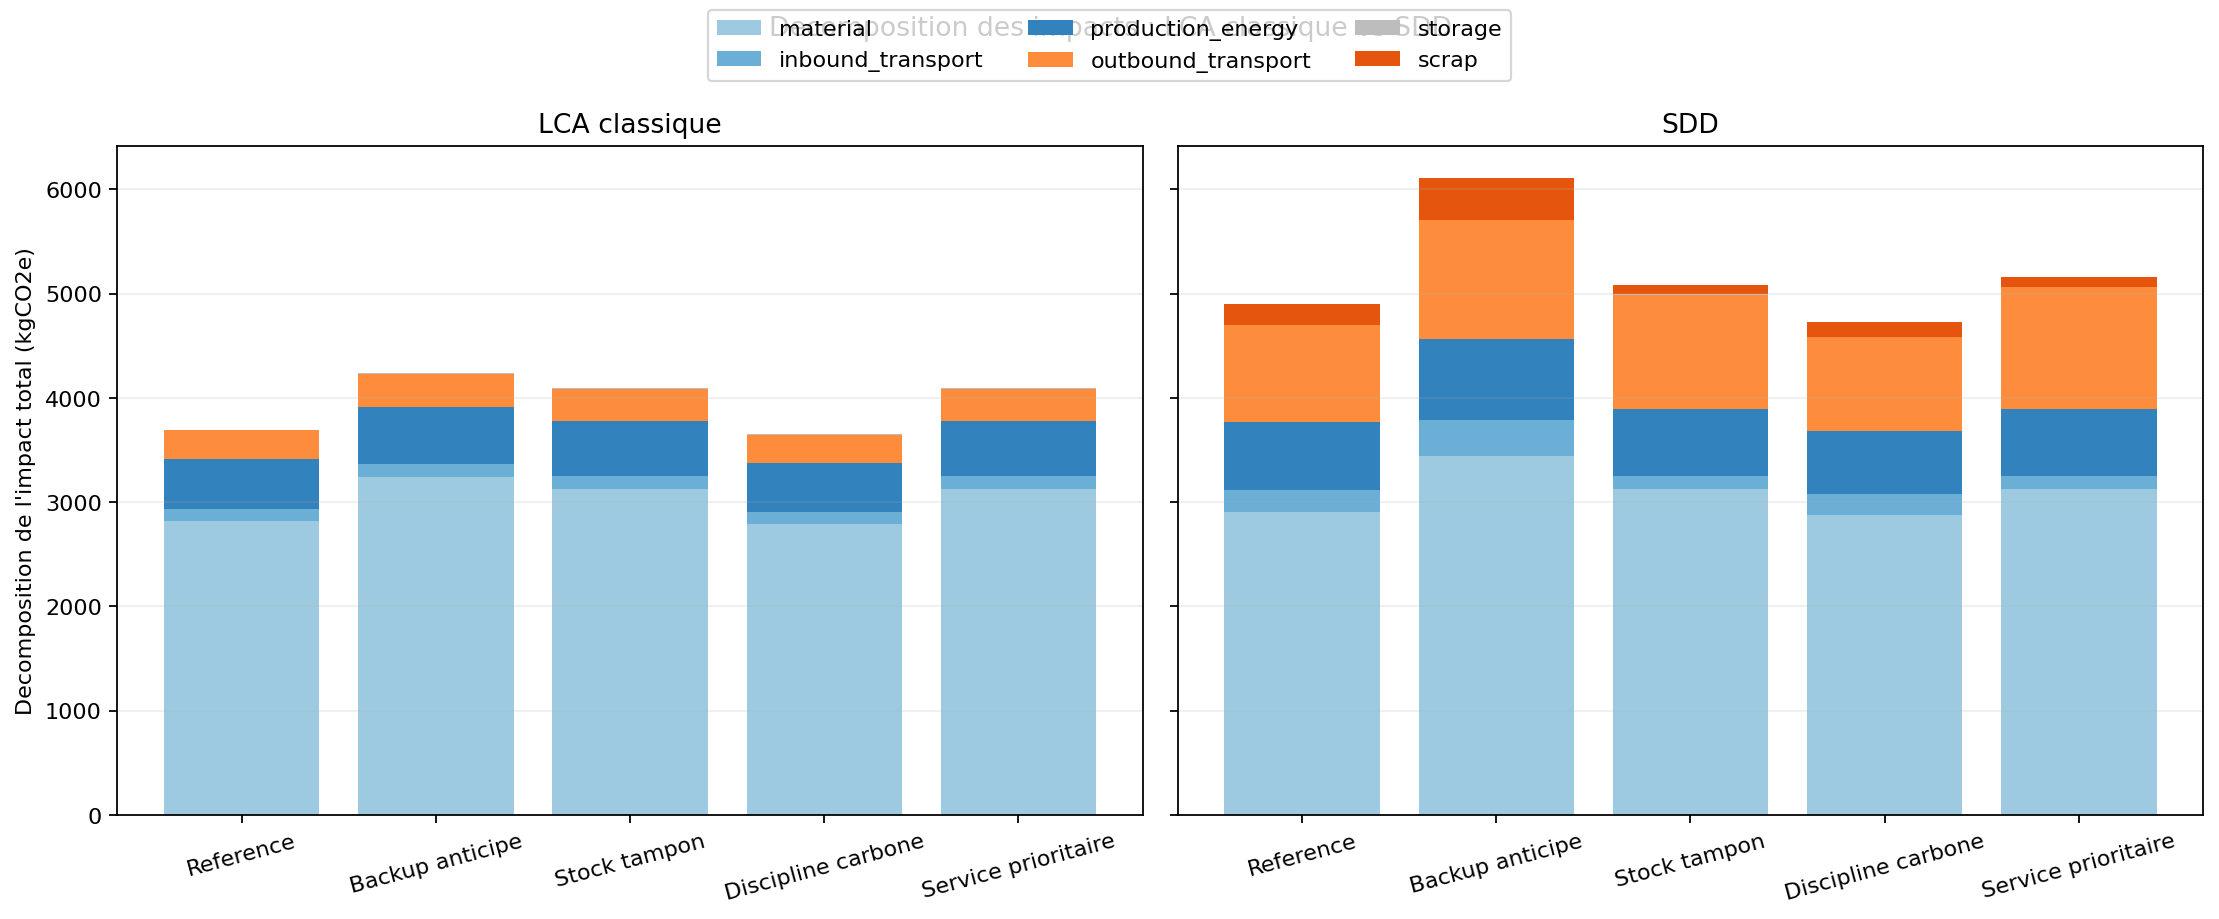

In [10]:
show_image('poc_policy_causal_attribution.png', width=1150)

### Focus scientifique : pourquoi le `scrap` ressort davantage en `SDD` ?

Le `scrap` est un point qui suscite souvent une question immediate : pourquoi est-il presque invisible dans les autres methodes alors qu'il devient visible en `SDD` ?

La reponse est structurelle :
- dans ce POC, la `LCA classique` et la `LCA dynamique` ne portent pas explicitement la charge carbone du rebut ;
- le `SDD` attribue au rebut la matiere, le transport amont et l'energie deja engages pour produire une unite qui ne sera jamais livree.

Scientifiquement, cela revient a dire que le `SDD` ne comptabilise pas seulement ce qui sort utilement du systeme, mais aussi ce qui a ete **consomme puis perdu**.

Operationnellement, cela veut dire que :
- une chaine sous tension produit non seulement moins bien ;
- elle detruit aussi davantage de valeur materielle et energetique ;
- cette destruction devient un poste carbone visible.

Question pertinente :
- **Pourquoi le `scrap` augmente-t-il souvent en meme temps que le `backup` ou l'aerien ?**
  Parce que ces signaux sont tous les symptomes d'un regime degrade : supply sous contrainte, capacite tendue, pilotage en urgence, moindre robustesse du systeme.


## Annexe B. Tracabilite de la production

Cette annexe sert a expliciter **d'ou viennent physiquement les produits finis utiles** et a quel moment le systeme commence a dependre du `backup`.

Comment lire le graphe :
- les barres empilees representent la `production utile`, c'est-a-dire les produits finis fabriques sans rebut pendant la semaine ;
- la decomposition des barres se fait par provenance : source principale versus source de secours ;
- la courbe noire represente le `backlog`, donc la demande non servie accumulee.

Ce que ce graphe montre scientifiquement :
- la perturbation ne change pas seulement le volume produit ; elle change aussi la **provenance** de ce qui est produit ;
- cette provenance compte pour le carbone, parce que le `backup` a dans ce POC des facteurs d'impact plus eleves ;
- la presence simultanee d'une hausse du `backlog` et d'une augmentation de la part `backup` signale une reconfiguration degradee de la chaine.

Questions pertinentes et reponses :
- **La production utile est-elle la meme chose que le stock de produits finis ?**
  Non. La production utile est un **flux** hebdomadaire ; le stock PF est un **stock** en fin de semaine.
- **Pourquoi le graphe montre-t-il la production utile et pas directement les expeditions client ?**
  Parce qu'il cherche a documenter l'origine de ce qui a ete produit, avant meme la question de l'expedition.
- **Pourquoi la provenance est-elle importante pour le `SDD` ?**
  Parce que le `SDD` ne calcule pas seulement des volumes : il attribue les impacts en tenant compte des regimes de sourcing et des conditions reelles de fonctionnement.


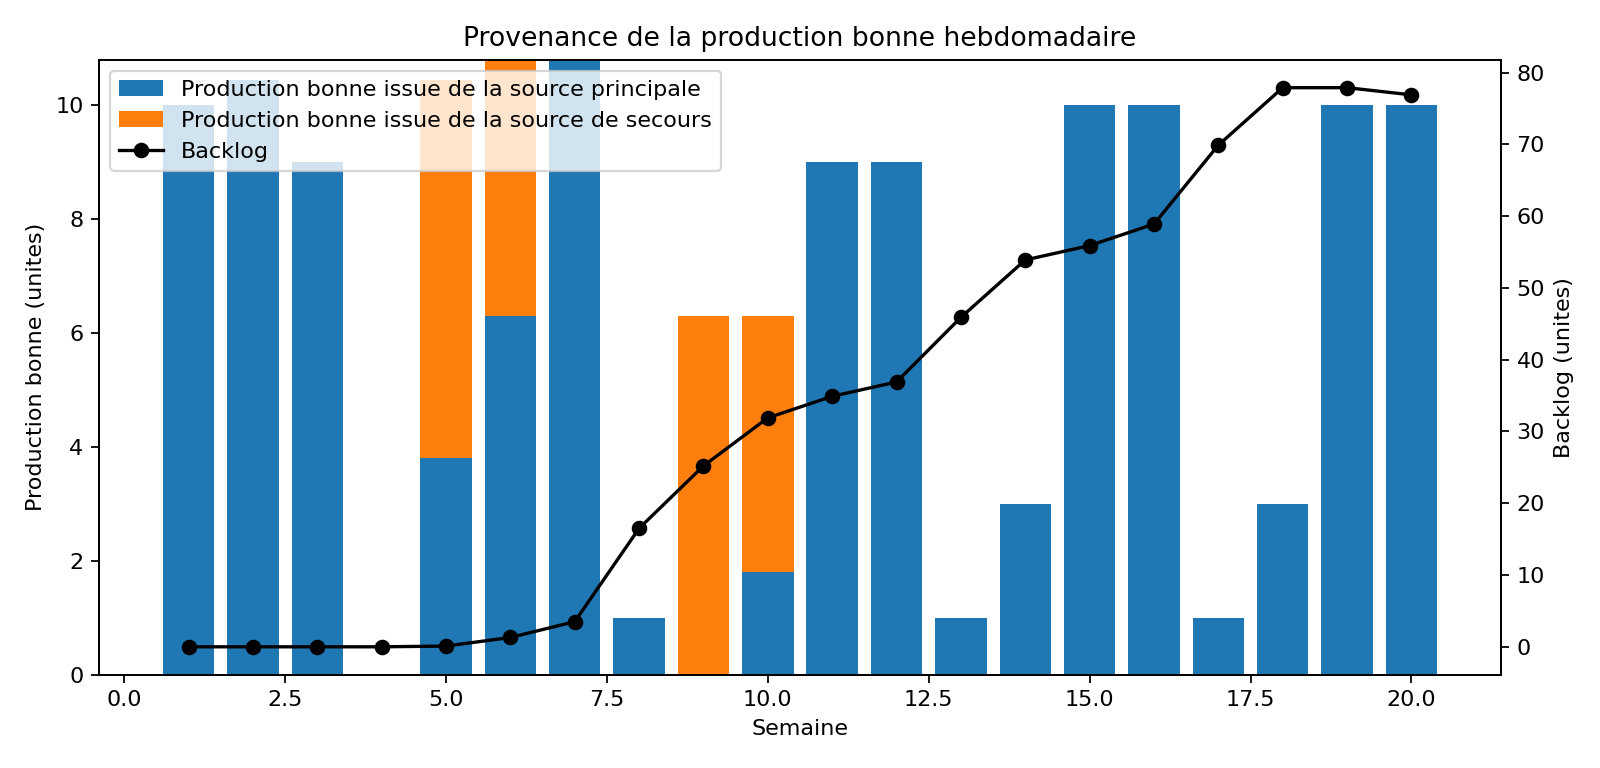

In [11]:
show_image('poc_source_traceability.png', width=1000)

## Annexe C. Projection d'etat du SDD

Cette annexe sert a expliciter la logique d'espace d'etat du POC.

Comment lire le graphe :
- Le panneau de gauche est une **projection reduite** de la trajectoire d'etat. On ne voit pas tout l'etat, mais un sous-ensemble interpretable : typiquement `stock MP`, `backlog` et `matieres en transit`.
- Le panneau de droite montre l'evolution temporelle de plusieurs composantes d'etat : `backlog`, `stock MP`, `stock PF`, `matieres en transit`.

Vocabulaire :
- `stock MP` : stock de matieres premieres, donc ce qui permet encore de produire ;
- `stock PF` : stock de produits finis deja fabriques mais non expedies ;
- `matieres en transit` : approvisionnements deja commandes mais non encore recus ;
- `backlog` : demande non servie, reportee a la semaine suivante.

Ce que ce graphe montre scientifiquement :
- l'impact du `SDD` est lie a la **trajectoire de l'etat**, pas seulement a une suite de flux isoles ;
- les transitions critiques apparaissent lorsque les stocks se contractent, que le backlog monte et que les matieres en transit ne suffisent plus a detendre le systeme ;
- le `SDD` est pertinent parce qu'il relie explicitement les emissions aux regimes internes de la chaine.

Questions pertinentes et reponses :
- **Pourquoi ne pas regarder seulement les expeditions client ?**
  Parce que les expeditions sont une consequence observable ; le `SDD` cherche a expliquer l'etat interne qui produit cette consequence.
- **Pourquoi les matieres en transit sont-elles importantes ?**
  Parce qu'un pipeline amont eleve peut masquer une tension immediate : la matiere existe, mais n'est pas encore disponible.
- **Pourquoi distinguer `stock MP` et `stock PF` ?**
  Parce qu'une rupture de matiere n'a pas le meme sens operationnel qu'une absence de produits finis disponibles pour le client.
- **Pourquoi parler de projection reduite ?**
  Parce que l'etat complet du systeme est multidimensionnel ; le graphe en montre seulement une vue interpretable.



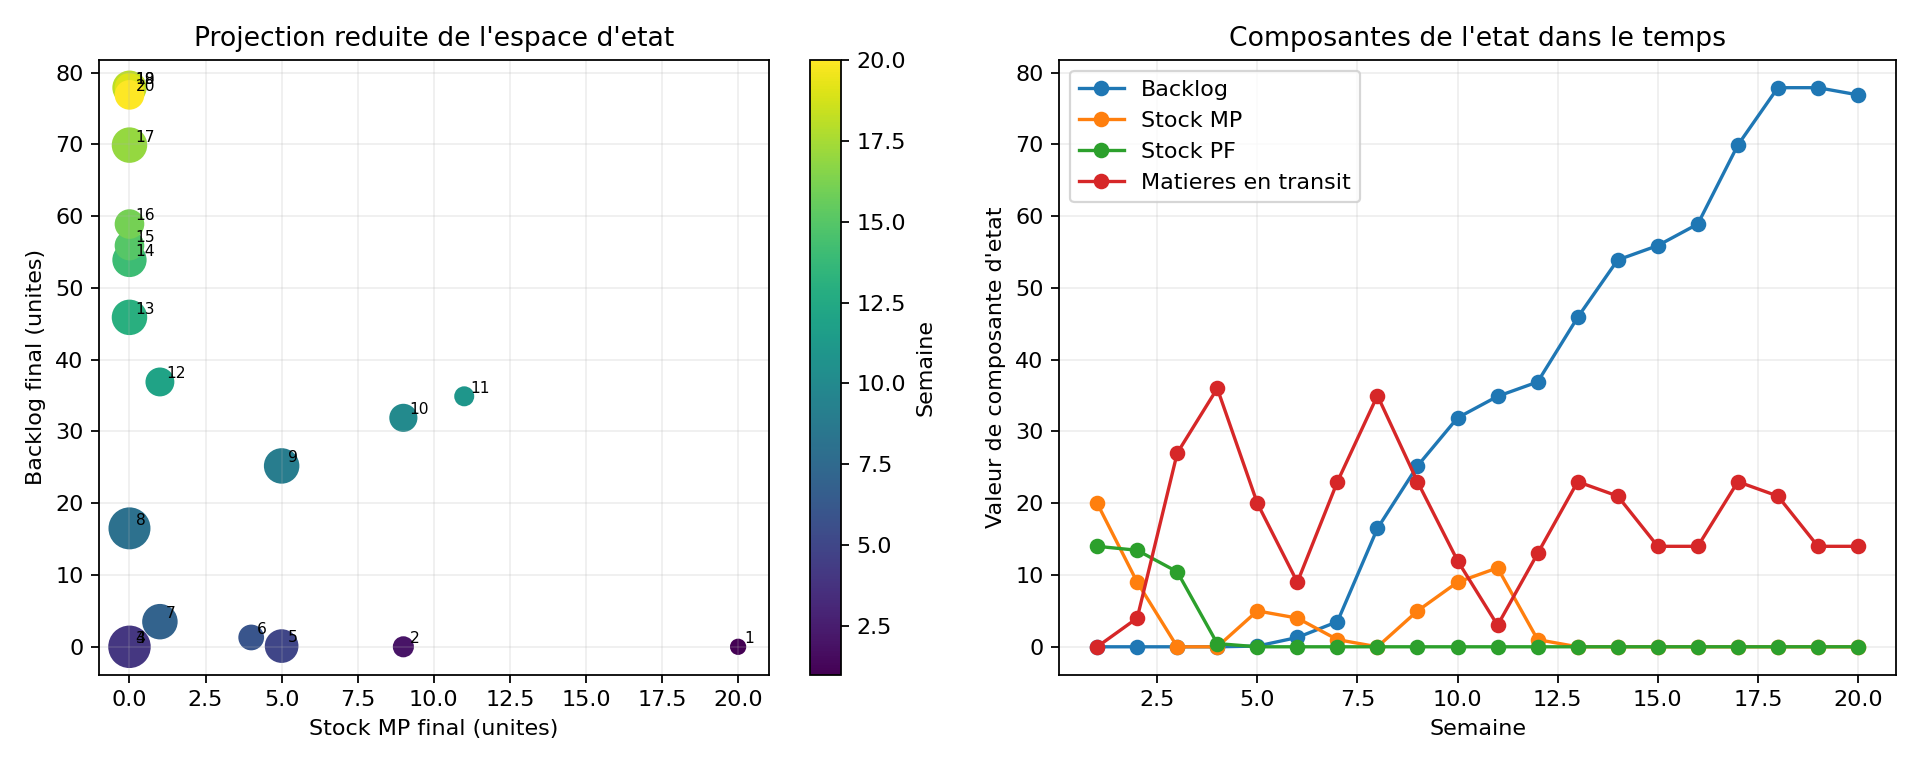

In [12]:
show_image('poc_state_space_projection.png', width=1050)

## Annexe D. Inversion de decision

Cette annexe montre un point fort du POC : il existe des cas ou la recommandation change selon la methode utilisee pour evaluer le carbone.

Comment lire le graphe :
- deux politiques sont comparees ;
- sur la ligne `LCA dynamique`, on regarde laquelle parait meilleure en carbone ;
- sur la ligne `SDD`, on refait exactement la meme comparaison.

Le point important est le suivant :
- la politique preferee par la `LCA dynamique` n'est pas necessairement celle preferee par le `SDD`.

Ce que cette figure demontre scientifiquement :
- le `SDD` n'est pas seulement une methode qui majore les impacts ;
- il peut modifier l'ordre relatif des options, donc changer la conclusion decisionnelle.

Questions pertinentes et reponses :
- **Pourquoi une inversion peut-elle apparaitre ?**
  Parce que deux politiques peuvent sembler proches si l'on regarde seulement des flux temporels moyens, alors qu'elles declenchent en realite des regimes differents : plus d'aerien, plus de backup, plus de backlog ou plus de rebut.
- **Pourquoi est-ce important pour l'operationnel ?**
  Parce qu'une methode qui preserve le mauvais classement peut conduire a retenir une politique sous-optimale du point de vue carbone reel.
- **Ce graphe prouve-t-il que le `SDD` est toujours meilleur ?**
  Il ne prouve pas une superiorite universelle ; il montre que, sur ce cas, la prise en compte des etats change effectivement l'evaluation et potentiellement la decision.


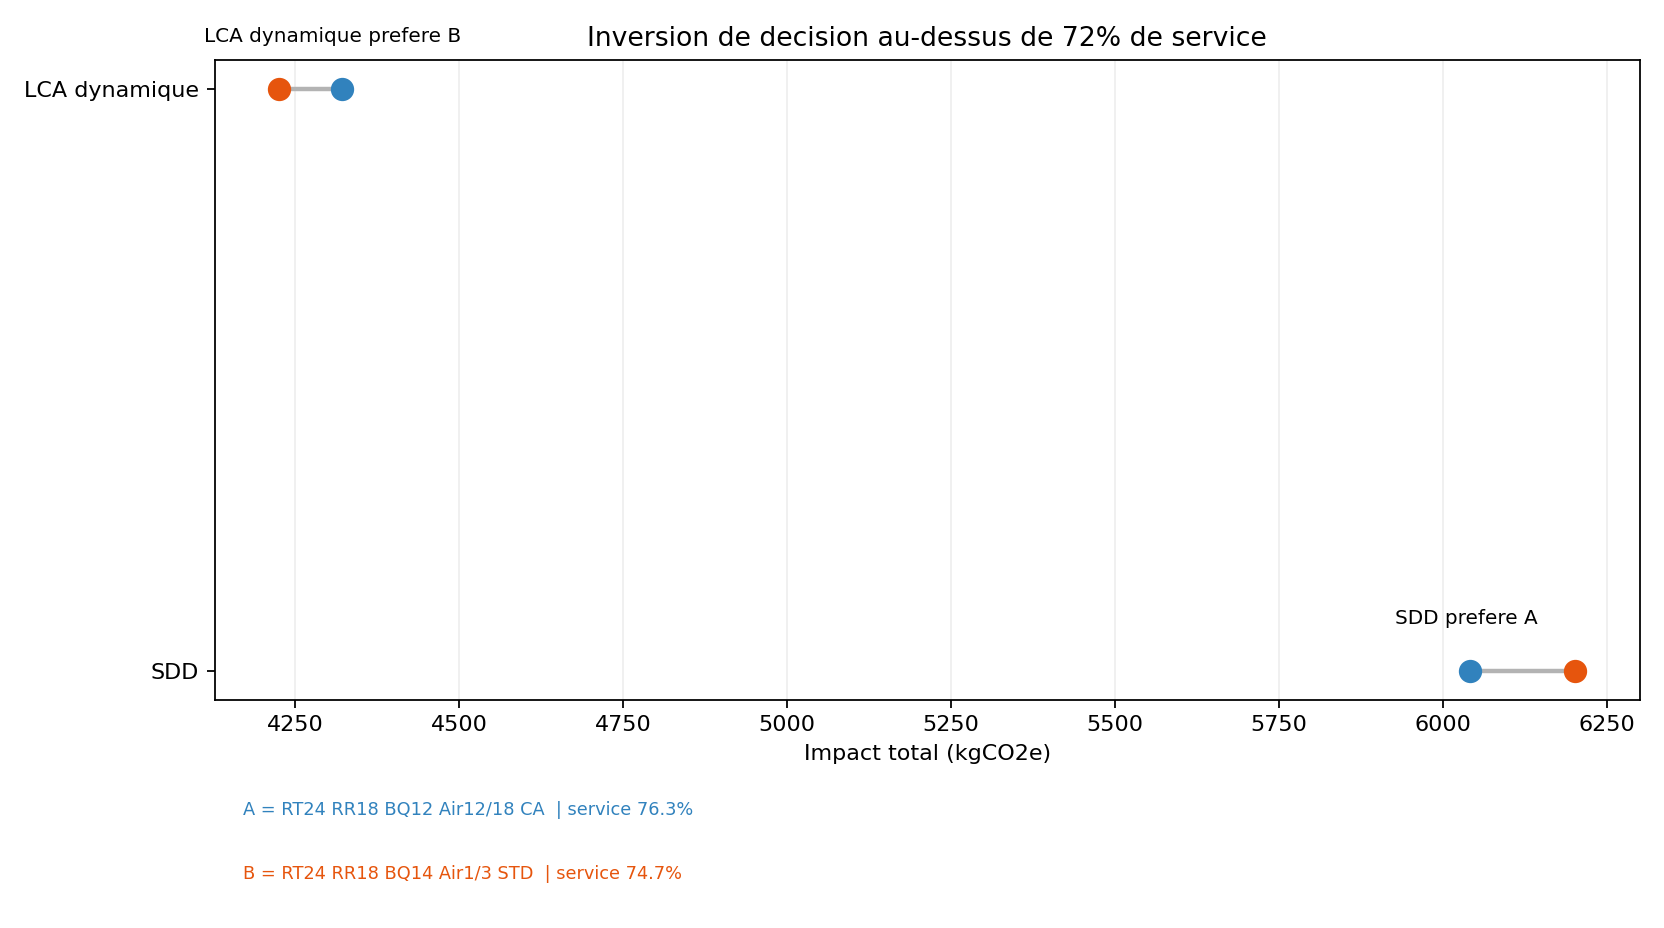

In [13]:
show_image('poc_decision_reversal.png', width=950)

## Annexe E. Sensibilite

Cette annexe sert a verifier que le message du POC ne depend pas d'un seul jeu de parametres.

Comment lire le graphe :
- un panneau montre les expeditions client totales ;
- un panneau montre l'intensite carbone par unite expediee pour la `LCA classique` ;
- un panneau montre l'intensite carbone par unite expediee pour le `SDD`.

Pourquoi ce format est important :
- regarder seulement les emissions absolues peut etre trompeur, car une disruption forte peut faire baisser les emissions simplement parce que le systeme sert moins de volume ;
- l'intensite par unite expediee permet de distinguer une baisse d'activite d'une vraie amelioration environnementale.

Ce que cette annexe montre :
- quand la disruption s'aggrave, les expeditions baissent souvent ;
- pourtant, l'intensite carbone par unite expediee peut rester elevee, voire augmenter ;
- le `SDD` reste plus sensible a cette degradation que la `LCA classique`.

Questions pertinentes et reponses :
- **Pourquoi les emissions totales peuvent-elles baisser quand la disruption devient plus severe ?**
  Parce que le systeme produit et expedie moins. Ce n'est pas une amelioration environnementale, c'est une contraction d'activite.
- **Pourquoi raisonner en intensite par unite expediee ?**
  Parce que cela permet de comparer la performance carbone independamment du volume effectivement servi.
- **Que montre alors le `SDD` de plus ?**
  Il montre que les regimes operationnels de crise detriorent le carbone par unite servie, meme quand les volumes baissent.


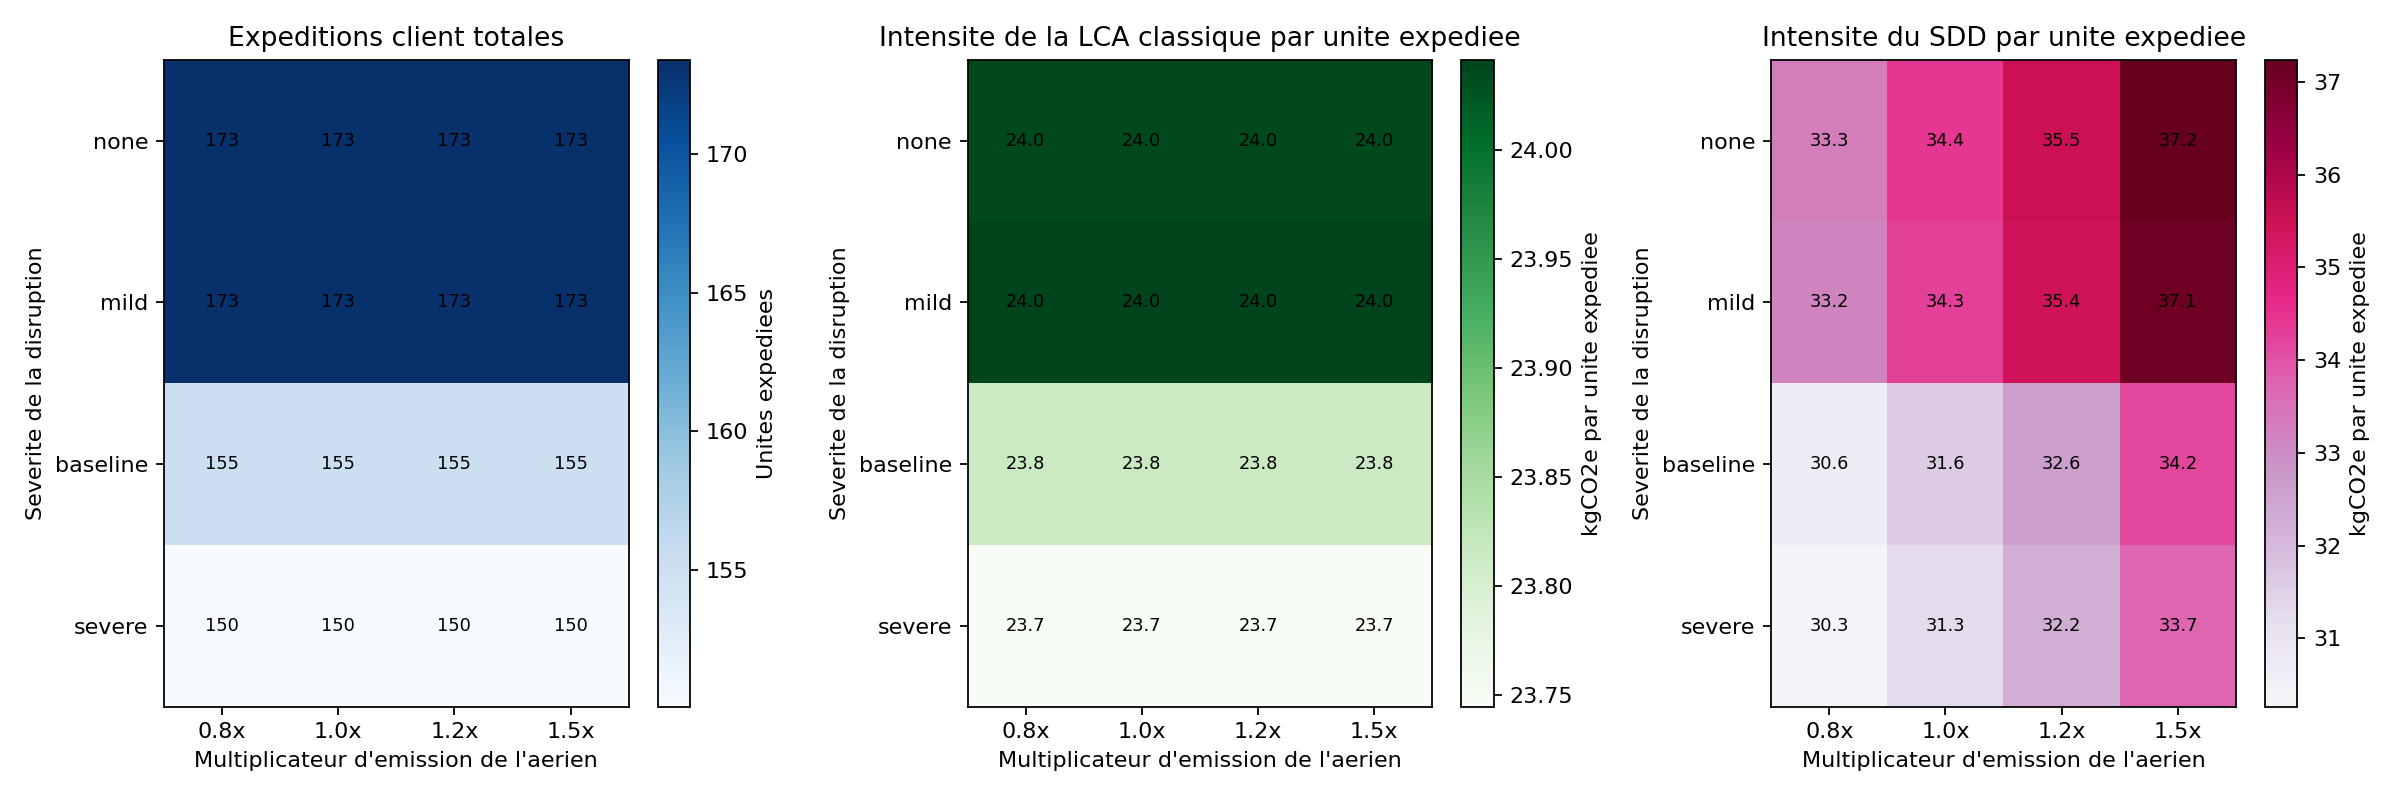

In [14]:
show_image('poc_sensitivity_volume_intensity.png', width=1150)